In [1]:
import requests
from bs4 import BeautifulSoup
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


In [2]:
url = "https://rate.bot.com.tw/xrt?Lang=zh-TW"
resp = requests.get(url)
resp.encoding = 'utf-8'
# print(resp.text) 

html_soup = BeautifulSoup(resp.text, "lxml")
rate_table = html_soup.find('table', attrs={'title':'牌告匯率'}).find('tbody').find_all('tr')

In [3]:
# 查詢英鎊(也就是匯率表的第3個元素)對台幣的匯率
currency = rate_table[2].find('div', attrs={'class':'visible-phone print_hide'})
print(currency.text.replace(" ", ""))  # 去掉所有的空白
buyin_rate = rate_table[2].find('td', attrs={'data-table':'本行現金買入'})
sellout_rate = rate_table[2].find('td', attrs={'data-table':'本行現金賣出'})
print("即時現金買入: {}, 即時現金賣出: {}".format(buyin_rate.get_text(), sellout_rate.get_text()))


英鎊(GBP)

即時現金買入: 40.19, 即時現金賣出: 42.31


In [4]:
cash_buy_list = []
cash_sell_list= []
currency_list = []
for rate in rate_table:
    #print(rate)
    prices = rate.find_all("td")
    #print(prices[1].text)
    cash_buy_list.append(prices[1].text)
    #print(prices[2].text)
    cash_sell_list.append(prices[2].text)

    currency_name = rate.find_all(class_="visible-phone print_hide")
    #print(currency_name[1].text.strip())
    currency_list.append(currency_name[1].text.strip())

In [5]:
df = pd.DataFrame()
df["貨幣"] = currency_list
df["現金買入"] = cash_buy_list
df["現金買出"] = cash_sell_list
df

,貨幣,現金買入,現金買出
0,美金 (USD),30.185,30.855
1,港幣 (HKD),3.758,3.962
2,英鎊 (GBP),40.19,42.31
3,澳幣 (AUD),19.45,20.23
4,加拿大幣 (CAD),21.62,22.53
5,新加坡幣 (SGD),23.3,24.21
6,瑞士法郎 (CHF),37.36,38.56
7,日圓 (JPY),0.1993,0.2121
8,南非幣 (ZAR),-,-
9,瑞典幣 (SEK),-,-


In [6]:
# 先到牌告匯率首頁，爬取所有貨幣的種類
url = "https://rate.bot.com.tw/xrt?Lang=zh-TW"
resp = requests.get(url)
resp.encoding = 'utf-8'
html = BeautifulSoup(resp.text, "lxml")
rate_table = html.find('table', attrs={'title':'牌告匯率'}).find('tbody').find_all('tr')

In [7]:
currency = rate_table[2].find(name='div', attrs={'class':'visible-phone print_hide'})
print(currency.get_text().replace(" ", ""))  # 貨幣種類


英鎊(GBP)



In [8]:
history_link = rate_table[2].find('td', attrs={'data-table':'歷史匯率'})
print(history_link)
history_rate_link = "https://rate.bot.com.tw" + history_link.a["href"]  # 該貨幣的歷史資料首頁
print(history_rate_link)

<td class="text-center print_hide phone-small-font" data-table="歷史匯率"><a href="/xrt/history/GBP?Lang=zh-TW" target="_blank" title="英鎊 歷史匯率 (另開視窗)">查詢</a></td>
https://rate.bot.com.tw/xrt/history/GBP?Lang=zh-TW


In [13]:
#到貨幣歷史匯率網頁，選則該貨幣的「歷史區間」，送出查詢後，觀察其網址變化情形，再試著抓取其歷史匯率資料
# 用’quote/西元年-月‘去更換網址，就可以連到該貨幣的歷史資料
quote_history_url = history_rate_link.replace("history", "quote/2025-08")
resp = requests.get(quote_history_url)
resp.encoding = 'utf-8'
history = BeautifulSoup(resp.text, "lxml")
history_table = history.find('table', attrs={'title':'歷史本行營業時間牌告匯率'}).find('tbody').find_all('tr')

In [14]:
date_history = []
history_buy = []
history_sell = []

for history_rate in history_table:
    # 擷取日期資料
    date_string = history_rate.a.get_text()
    date = datetime.strptime(date_string, "%Y/%M/%d").strftime("%Y/%M/%d")  # 轉換日期格式
    date_history.append(date)  # 日期歷史資料

    history_ex_rate = history_rate.find_all(name='td', attrs={'class':'rate-content-cash text-right print_table-cell'})
    history_buy.append(float(history_ex_rate[0].get_text()))  # 歷史買入匯率
    history_sell.append(float(history_ex_rate[1].get_text()))  # 歷史賣出匯率

<Figure size 1000x800 with 0 Axes>

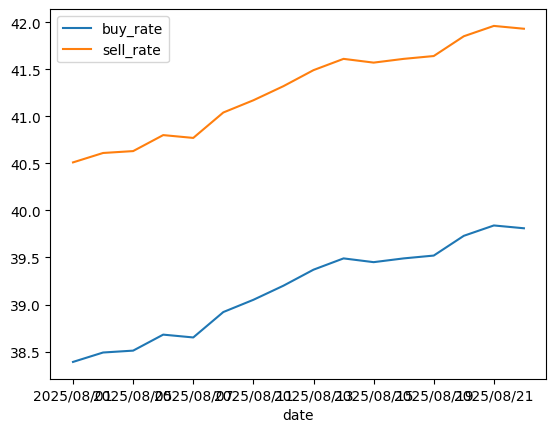

In [15]:
# 將匯率資料建成dataframe形式
History_Ex_Rate = pd.DataFrame({'date': date_history, 'buy_rate':history_buy, 'sell_rate':history_sell})

History_Ex_Rate = History_Ex_Rate.set_index('date')  # 指定日期欄位為datafram的index
History_Ex_Rate = History_Ex_Rate.sort_index(ascending=True)
# 畫出歷史匯率軌跡圖
plt.figure(figsize=(10, 8))
History_Ex_Rate[['buy_rate','sell_rate']].plot()  # x=['date'], y=[['buy_rate','sell_rate']] 
plt.legend(loc="upper left")
plt.show()

In [16]:
# 建立 DataFrame
History_Ex_Rate = pd.DataFrame({
    'date': date_history,
    'buy_rate': history_buy,
    'sell_rate': history_sell
})

# 確保日期排序
History_Ex_Rate = History_Ex_Rate.sort_values('date')

# 使用 Plotly 畫互動折線圖
fig = px.line(
    History_Ex_Rate,
    x='date',
    y=['buy_rate', 'sell_rate'],
    title='歷史匯率折線圖',
    labels={'value': '匯率', 'date': '日期', 'variable': '種類'}
)

fig.show()